--- First Few Records ---
   House_Size  House_Price
0         600           25
1         800           32
2        1000           38
3        1200           45
4        1400           52


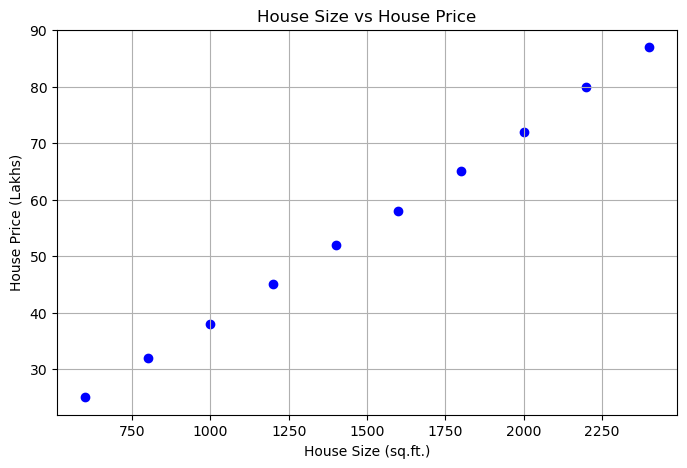


Task 5 - Regression Constant (theta_0): 4.4331
Task 5 - Regression Coefficient (theta_1): 0.0339
   Actual  Predicted
8      80  85.808917
1      32  45.121019
   House_Size  Predicted_Price
0        1500        55.292994
1        1700        62.074310
2        2500        89.199575


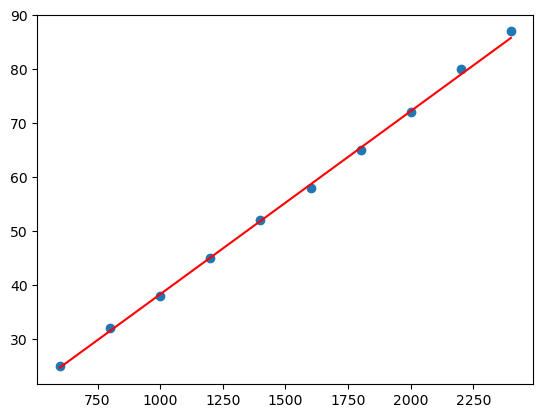

Interpretation: The line closely fits the points, showing house price increases steadily with size.
MAE: 9.4650
MSE: 102.9523
RMSE: 10.1465
R2 Score: 0.8213


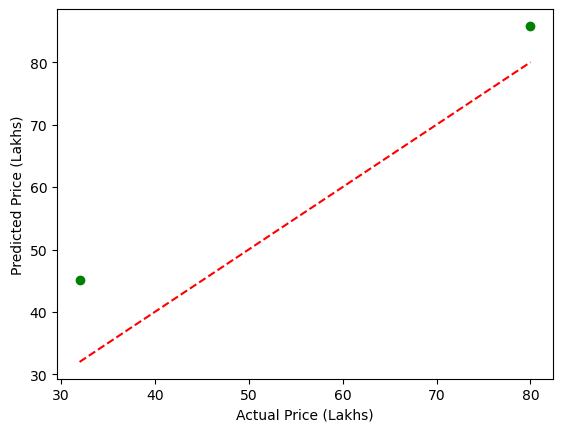

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

data = {
    'House_Size': [600, 800, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400],
    'House_Price': [25, 32, 38, 45, 52, 58, 65, 72, 80, 87]
}
df = pd.DataFrame(data)
print("--- First Few Records ---")
print(df.head())


plt.figure(figsize=(8, 5))
plt.scatter(df['House_Size'], df['House_Price'], color='blue', label='Data Points')
plt.title('House Size vs House Price')
plt.xlabel('House Size (sq.ft.)')
plt.ylabel('House Price (Lakhs)')
plt.grid(True)
plt.show()

X = df[['House_Size']]
Y = df['House_Price']
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2)
model = LinearRegression()
model.fit(X_train,Y_train)

print(f"\nTask 5 - Regression Constant (theta_0): {model.intercept_:.4f}")
print(f"Task 5 - Regression Coefficient (theta_1): {model.coef_[0]:.4f}")

y_pred_test = model.predict(X_test)
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_test})

print(comparison)

new_sizes = pd.DataFrame({'House_Size': [1500, 1700, 2500]})
new_sizes['Predicted_Price'] = model.predict(new_sizes)

print(new_sizes)

plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red')
plt.show()

print("Interpretation: The line closely fits the points, showing house price increases steadily with size.")

mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")


plt.scatter(y_test, y_pred_test, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.show()


